# Agrupación

## Análisis de Componentes Principales

A diferencia del análisis de factores, el Análisis de Componentes Principales no es un método analítico, pero un método de transformación lineal ortogonal que mapea los datos originales en un nuevo sistema de coordenadas que busca maximizar la varianza de las extrapolaciones.

Por lo general el análisis busca representar un conjunto $\mathbb{N}$-dimensional de datos en un primer eje (aquél que maximize más la varianza), y un segundo eje (el segundo componente que maximize la varianza).

Si tenemos una matriz de datos originales $X$, podemos obtener la matriz transformada $\widetilde{X}$ mediante un argumento de transformación lineal $P$, que generalmente toma una forma geométrica (rango y rotación).

$$\widetilde{X} = P \cdot X$$

El Análisis de Componentes Principales busca reducir la redundancia de los datos entre una serie de expansiones basales candidatas. Aquella que aproxime su matriz de covarianza a una matriz diagonal (entradas diagonales cercanas a 1 y triángulos cercanos a 0), se denomina como el primer componente principal.

El proceso se itera, rankeando todas las expansiones basales en términos de maximización de varianza y reducción de redundancia de datos. El proceso se ilustra en la figura `gfx.pca_variance()`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
import seaborn as sns
import lec7_graphs as gfx

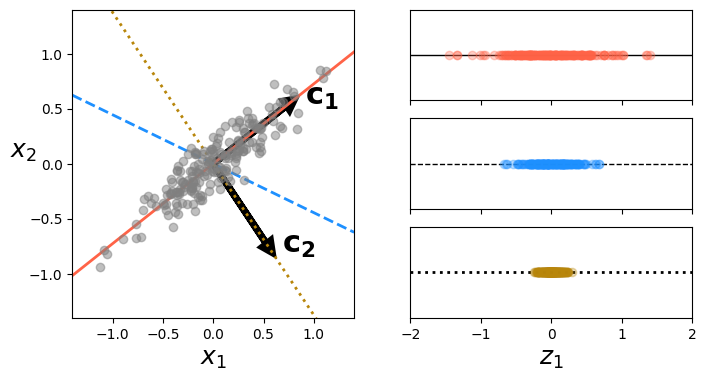

In [2]:
gfx.pca_variance()

En el gráfico izquierdo se presenta un diagrama de dispersión entre dos variables $x_1$ y $x_2$ que presentan una relación bivariada positiva. El objetivo del análisis de componentes principales es obtener dimensiones que capturen y mapeen la varianza conjunta.

En el siguiente caso se presentan 3 rectas asociadas a los principales eigenvalues. En el lado derecho del gráfico se presenta la cantidad de varianza capturada (dado $z_1$) por cada una de las dimensiones.

La recta roja se posiciona como la dimensión que captura una parte substancial de la varianza conjunta entre $x_1$ y $x_2$ , dado que pasa de a lo largo de la tendencia. En segundo lugar, la recta amarilla captura una mayor parte de la varianza en comparación a la tercera dimensión representada en la recta azul.

Optamos por la recta amarilla por sobre la azul dado que ésta preserva la ortogonalidad de la matriz de datos (existe un ángulo de 90 grados entre ambas, lo cual implica que no hay covarianza entre éstas dimensiones).

Supongamos que deseamos restringir nuestra reducción a las dos principales dimensiones que maximizen la varianza capturada. Nuestro criterio de selección mantendría las rectas roja (asignándole un $c_1$) y amarilla (asignándole un $c_2$)
Existen una serie de supuestos asociados:
- *Linealidad*: La nueva expansión basal **es una expresión lineal de la base original**.
- *Media y varianza*: Media y varianza son estadísticas suficientes para describir la distribución empírica de los datos. $\mathcal{N}(0, \sigma^2)$ es idóneo.
- *SNR (Signal Noise Ratio)*: PCA asume que las dinámicas tienen un alto rango de señal por sobre ruido (es un método varianza-dependiente).
- *Ortonormalidad de los componentes*: tienen norma 1 y producto de 0.

### Digresión: Decomposición de Valores Singulares (SVD)

Otra alternativa para encontrar los eigenvalues de una matriz de datos es mediante la decomposición de valores singulares. Esta busca separar la matriz en tres componentes, siguiendo la fórmula

$$X = U \cdot \Sigma \cdot V^T$$

Donde:
- $U$ es una matriz que representa la matriz ortogonal de las columnas.
- $\Sigma$ es una matriz que representa la matriz diagonal.
- $V$ es una matriz que representa la matriz ortogonal de las filas.

El efecto de ésta última es generar una medición de la importancia relativa de cada columna y fila de la matriz $X$.

La principal diferencia entre PCA y SVD es que la primera obtiene las dimensiones mediante la maximización de la varianza $d$ en dimensión, y SVD obtiene las dimensiones mediante la medición de la importancia relativa.

SVD se considera numéricamente más estable y puede ser más eficiente en estimar las dimensiones.

## Identificando números escritos

Una de las principales aplicaciones del PCA es la reducción de dimensionalidad cuando tenemos muchos más atributos que observaciones. Un ejemplo clásico de esto es el reconocimiento de imágenes, una imagen se compone de una serie de pixeles distribuídos de forma cuadrada o rectangular.

Durante este ejemplo utilizaremos la base de datos MNSIT de números escritos a mano disponibles [aca](http://yann.lecun.com/exdb/mnist/). Partamos por ver la representación nativa de un número en la base. La base de datos se encuentra como parte de scikit-learn .

In [3]:
from sklearn.datasets import load_digits
df = load_digits()

Solicitemos el array 8 de esta base de datos. La información viene en un array unidimensional como representación nativa. Cada uno de los valores fluctúa entre 0 y 1, donde mayores valores representan saturaciones mayores en la escala de grises. Vamos a reacomodar el array a una matriz de $8 \times 8$ con reshape .

In [4]:
df.data[8].reshape([8,8])

array([[ 0.,  0.,  9., 14.,  8.,  1.,  0.,  0.],
       [ 0.,  0., 12., 14., 14., 12.,  0.,  0.],
       [ 0.,  0.,  9., 10.,  0., 15.,  4.,  0.],
       [ 0.,  0.,  3., 16., 12., 14.,  2.,  0.],
       [ 0.,  0.,  4., 16., 16.,  2.,  0.,  0.],
       [ 0.,  3., 16.,  8., 10., 13.,  2.,  0.],
       [ 0.,  1., 15.,  1.,  3., 16.,  8.,  0.],
       [ 0.,  0., 11., 16., 15., 11.,  1.,  0.]])

La matriz retornada aún resulta poco intuitiva, porque está diseñada para ser interpretada de forma eficiente por el computador y no el ojo humano. Implementaremos el método `imshow` de `matplotlib` para generar una representación "más afable" al ojo humano.

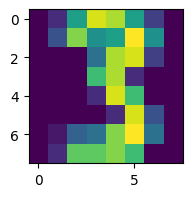

In [5]:
plt.figure(figsize=(2,2))

plt.imshow(df.data[13].reshape([8, 8]));

La matriz equivale al número 8. Nuestro objetivo es abstraer las principales características de los trazos al momento de escribir. Para ello implementaremos un Análisis de Componentes Principales. Su implementación se encuentra en la clase PCA del módulo decomposition de la librería `sklearn`.

## Reduciendo dimensiones

Sabemos que la representación afable para el computador es una matriz con 64 columnas, donde cada una representa un porcentaje en la escala de grises. Esta representación es poco afable para nosotros.

In [6]:
print("Dimensión original de la base:",df.data.shape)

Dimensión original de la base: (1797, 64)


Implementemos un modelo de reducción a dos dimensiones, asumiendo que ésta es la representación más afable para el ojo humano. Partamos por importar `PCA`.

El primer paso es instanciar un objeto con la clase `PCA` donde ingresamos el número de componentes que deseamos extraer con el argumento `n_components`. En este caso lo realizaremos con 2.

Posterior a la creación de objeto, podemos ingresar los datos mediante `fit_transform`. La función ejecutará dos procesos:

1. *Estandarización*: De manera similar al análisis de factores, centrar los datos (hacer que cada vector tenga media 0 y error estandar unitario) facilita la implementación y estimación de matrices de covarianza. De esta manera el método llama de forma interna al `StandardScaler` que utilizamos en la unidad de clasificación logística.

2. *Implementación del modelo*: Posteriormente ingresa los datos al método que decompone la matriz a una serie de eigenvalues.

In [7]:
from sklearn.decomposition import PCA
dimred = PCA(n_components = 2)
project_x = dimred.fit_transform(df.data)

La implementación del modelo la guardamos en el objeto `project_x`. Si solicitamos las dimensiones con `shape`, observamos que pasamos de 64 a 2 columnas.

In [8]:
print("La nueva dimensión de la base es de:",project_x.shape)

La nueva dimensión de la base es de: (1797, 2)


## ¿Y qué significa todo esto?

Hasta el momento hemos realizado una serie de transformaciones, pero no obtenemos resultados tangibles al respecto. Lo que podemos hacer es graficar cada una de las dos dimensiones para intentar hacer sentido al respecto.

Implementaremos un diagrama de dispersión con el método `plt.scatter`, donde ingresamos cada una de las dimensiones y modificamos los atributos visuales de los puntos para identificar cada número con `df.target`. Finalmente implementamos `colorbar` para añadir una legenda discreta a cada valor.

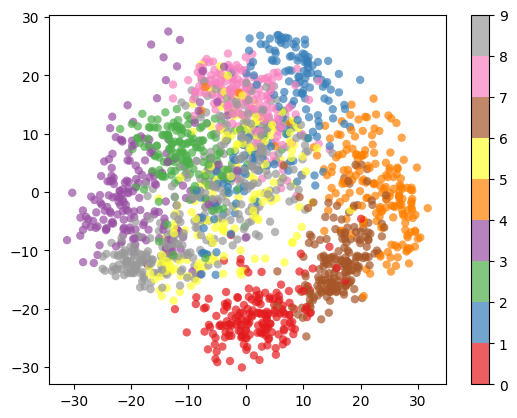

In [9]:
plt.scatter(project_x[:, 0], project_x[:, 1], c=df.target, edgecolor='none', alpha=.7, cmap='Set1')
plt.colorbar()
plt.show()

Resulta que ambas dimensiones representan atributos sobre los trazos de los números. Los trazos entre los 4 y los 9 tienden a ser similares de igual manera que 7 y 5.

## Maximizando varianza

Retomemos el significado del Análisis de Componentes Principales: **buscar aquellas dimensiones que maximicen la varianza total de una matriz finita de datos**.

Así, parte importante de la implementación de PCA es el estimar cuántos elementos son necesarios para obtener el máximo de varianza explicada. Solicitemos la varianza explicada de cada dimensión de nuestro primer modelo.

In [10]:
print("La varianza explicada de cada dimensión es de:",dimred.explained_variance_ratio_)
print("En conjunto, ambas dimensiones explican la varianza en un: ", sum(dimred.explained_variance_ratio_))

La varianza explicada de cada dimensión es de: [0.14890594 0.13618771]
En conjunto, ambas dimensiones explican la varianza en un:  0.28509364823699296


Estos números se pueden mejorar de forma substancial. Para obtener una evaluación agnóstica de la cantidad de dimensiones, podemos instanciar un objeto `PCA` sin declarar la cantidad de dimensiones en `n_components`. Esta información la graficaremos de la siguiente manera:
1. Primero extraemos la cantidad de dimensiones estimadas por el modelo. Un punto a mencionar es que el límite superior de la cantidad de dimensiones es $\widetilde{X}_d=p$.
2. Graficaremos el porcentaje de varianza explicada de cada elemento en barras verticales.
3. Para visualizar la varianza acumulada a lo largo de las dimensiones, utilizamos `plt.step`.

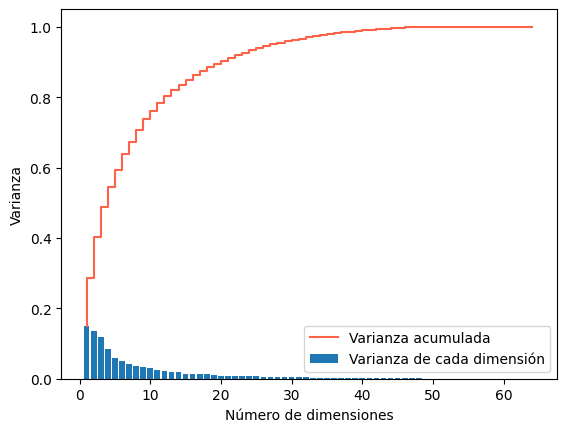

In [11]:
fetch_dims = PCA().fit(df.data)
dims_quant = len(fetch_dims.components_)

plt.bar(range(1, dims_quant + 1),fetch_dims.explained_variance_ratio_,label="Varianza de cada dimensión")
plt.step(range(1,len(fetch_dims.components_) + 1), np.cumsum(fetch_dims.explained_variance_ratio_), color='tomato', label="Varianza acumulada")
plt.xlabel('Número de dimensiones')
plt.ylabel('Varianza')
plt.legend()
plt.show()

Se observa que con alrededor de 10 dimensiones alcanzamos un 80% de varianza explicada. Después de la 10 dimensión la curva de varianza acumulada tiende a suavizarse, y cuando se alcanzan 30 dimensiones la cantidad de varianza explicada por cada dimensión es cercana a 0.

Refactoricemos nuestro modelo con $d=10$. Explicamos un 74% de la varianza con 10 dimensiones.

In [12]:
pca = PCA(n_components=10)
project_x = pca.fit_transform(df.data)
print("Varianza acumulada con 10 dimensiones:", np.cumsum(pca.explained_variance_ratio_)[-1])

Varianza acumulada con 10 dimensiones: 0.7382267688459532


## ¿Qué significa cada componente?

Hasta el momento sabemos el objetivo general del PCA y cómo refactorizar el modelo para aumentar su capacidad explicativa. Pero cada una de las dimensiones resume parte importante de cómo se efectúa cada traza que permite identificar un número.

Sabemos que cada número en la base está representado por un array de 64 dígitos entre 0 y 1.

In [13]:
df.data[6]

array([ 0.,  0.,  0., 12., 13.,  0.,  0.,  0.,  0.,  0.,  5., 16.,  8.,
        0.,  0.,  0.,  0.,  0., 13., 16.,  3.,  0.,  0.,  0.,  0.,  0.,
       14., 13.,  0.,  0.,  0.,  0.,  0.,  0., 15., 12.,  7.,  2.,  0.,
        0.,  0.,  0., 13., 16., 13., 16.,  3.,  0.,  0.,  0.,  7., 16.,
       11., 15.,  8.,  0.,  0.,  0.,  1.,  9., 15., 11.,  3.,  0.])

La representación aproximada de una imagen mediante PCA se realiza en base a la **combinación lineal de factores**. En este caso optimizamos nuestro algoritmo para extraer las primeras 10 dimensiones que representen el mapeo de un número, por lo que la representación de una imagen se lograría:

$$\text{Imagen}(x) = \mu + \sum_{i=1}^{10} \lambda_i x_i$$

Así, la reconstrucción de cada imagen es una conjetura de coeficientes $\lambda_i$ estimados y multiplicados por la matriz entre 0 y 1 de las trazas.

Podemos visualizar el proceso de reconstrucción de imágenes con el siguiente código con la función `plot_pca_components`.

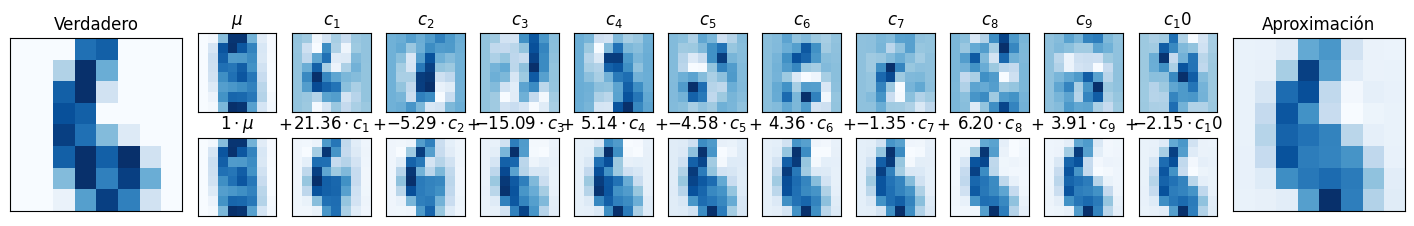

In [14]:
gfx.plot_pca_components(df.data[6], project_x[6], pca.mean_, pca.components_);

## Algoritmos de agrupación

A lo largo de la lectura estudiamos la reducción de dimensionalidad como un método de aprendizaje no supervisado: tenemos una matriz de datos y nosotros tenemos poca información sobre cómo se comportan las dimensiones latentes.

El otro método de aprendizaje es la agrupación (o clustering en la jerga inglesa). La tarea principal de los algoritmos de agrupación es **dividir los datos en una serie de grupos en base a alguna medida de similitud entre los puntos**. Si bien la agrupación busca asignar etiquetas de similar manera que las estrategias de clasificación, en los métodos de agrupación **no tenemos certeza sobre la cantidad de grupos emergentes**.

Implementar algoritmos de agrupación dentro del flujo de análisis facilita la representación de la estructura de los datos así como el descubrimiento de nuevos patrones.

## KMeans

La idea de kMeans es desarrollar una segmentación de vectores en un espacio $d$-dimensional de manera tal de inferir grupos que no se sobrepongan. El método clásico para obtener una serie de clusters se basa en:

1. Asignar una cantidad de $k$ clusters: Por lo general el investigador debe probar con distintos valores de $k$.
2. Asignar a cada observación en el espacio al cluster **más cercano**: Los clusters se generan a partir de la media aritmética de todos los puntos cercanos al cluster.
3. Por cada cluster, actualizar su centroide como la media para todos sus puntos asignados.
4. Iterar los puntos 2 y 3 hasta que se satisfaga algún criterio.

## Implementación

Para demostrar la aplicación de kMeans generaremos un caso artifical con `make_blobs`, que permite generar "grupos de datos siguiendo una función Gausiana Isotrópica". Por Gausiana entendemos una distribución normal, y por Isotrópica entendermos una distribución normal donde la matriz de covarianza se simplifica a la matriz de identidad $\Sigma = \sigma^2 I$.

La función `make_blobs` se encuentra en el módulo `datasets` de la librería `sklearn`. La función necesita de la cantidad de casos a simular en total definidos en `n_clusters` , así como los parámetros media (`centers`) y varianza (`cluster_std`). En este caso generamos un array de arrays donde definimos las coordenadas de cada blob a generar, así como un array que contiene la varianza asociada a cada blob. Como con toda simulación, es necesario definir una semilla pseudoaleatoria para asegurar replicabilidad de los resultados.

`make_blobs` retornará las coordenadas para cada punto en el objeto `X_mat` y la pertenencia de cada punto a alguna agrupación.

Para este caso estamos simulando 3000 casos repartidos en 7 grupos.

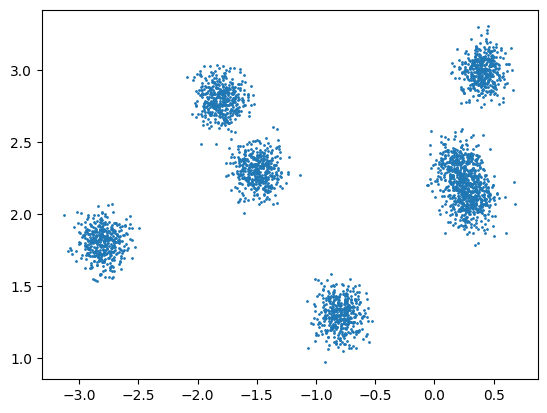

In [15]:
# importamos make_blobs
from sklearn.datasets import make_blobs
# Definimos los centros
bivariate_mu_params = list([[ 0.2, 2.3], [-1.5 , 2.3], [-2.8, 1.8], [-1.8, 2.8], [-.8, 1.3],[.3, 2.1], [.4, 3]])
# Definimos las varianzas
bivariate_sigma_params = list([0.1, 0.1, 0.1, 0.1, 0.1, .1, .1])
X_mat, y_vec = make_blobs(n_samples=3000, centers=bivariate_mu_params, cluster_std=bivariate_sigma_params, random_state=17250)
plt.scatter(X_mat[:, 0], X_mat[:, 1], s=1)
plt.show()

Para implementar `KMeans`, lo importamos desde el módulo `cluster` de la librería `sklearn`. La forma más fácil de instanciar una clase `KMeans`, asignamos la cantidad de grupos a identificar (que se declara en `n_clusters`) y una semilla pseudoaleatoria para replicabilidad (declarada con `random_state`).

Existen más especificaciones en esta etapa como `n_init` que define la cantidad de veces que el algoritmo será iniciado con distintos centroides, así como `max_iter` que define la cantidad máxima de iteraciones en una etapa.

In [16]:
# importamos el modulo
from sklearn.cluster import KMeans
# instanciamos KMeans en un nuevo objeto
kmeans = KMeans(n_clusters=7, random_state=11238)
# obtenemos los resultados
fit_results = kmeans.fit_predict(X_mat)

In [17]:
kmeans.labels_

array([0, 2, 1, ..., 5, 1, 4], shape=(3000,), dtype=int32)

In [18]:
pd.Series(kmeans.labels_).value_counts('%')

2    0.285667
1    0.143000
5    0.143000
0    0.142667
4    0.142667
6    0.080667
3    0.062333
Name: proportion, dtype: float64

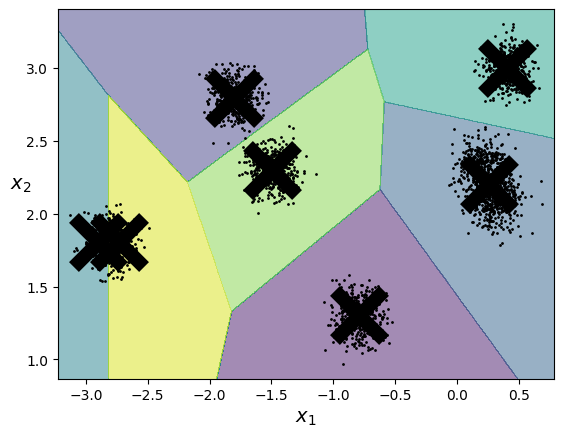

In [19]:
gfx.plot_decision_boundaries(kmeans, X_mat)

## Inercia del modelo

Si bien no podemos medir el desempeño del modelo (porque no tenemos etiquetas previas), podemos medir la distancia promedio entre cada número y su centroide mediante la inercia, entendida como la suma de distancias cuadráticas. Esto lo logramos mediante la métrica de inercia.

Podemos obtener la inercia de un modelo creado con `KMeans` al solicitar `.inertia_`. En este caso la inercia asociada al modelo cuando estimamos 7 clusters es de 56.

In [20]:
kmeans.inertia_

69.3194342935305

**¿Cuál es el resultado esperado respecto a la inercia de un modelo?** Buscamos aquél que presente una reducción substancial de las distancias cuadráticas entre los puntos y sus centroides. Así, estamos frente a una estrategía de minimización de pérdidas.

De manera similar al promedio del error cuadrático en los modelos lineales, la inercia sólo tiene sentido en la medida que comparamos entre múltiples candidatos. Para ello vamos a estimar la inercia cuando aumentamos la cantidad de clusters de 1 a 10 en pasos de a 1. Compararemos la inercia de cada modelo candidato mediante un gráfico.

Text(0.5, 1.0, 'Elbow graph')

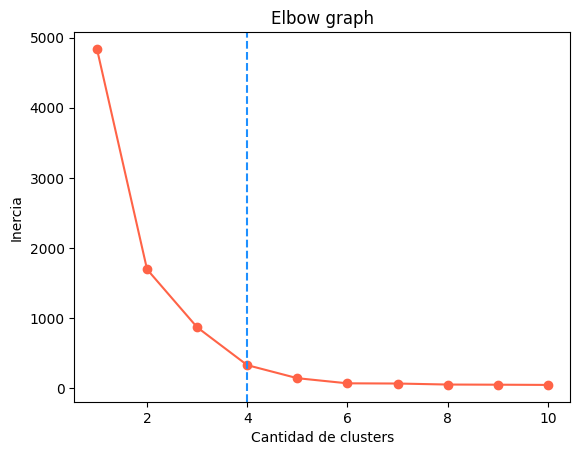

In [21]:
# generamos un array para guardar los resultados.
inertia = []
# Para cada número entre 1 y 10
for i in range(1, 11):
    # Agregamos la inercia
    inertia.append(KMeans(n_clusters=i, random_state=11238).fit(X_mat).inertia_)
# graficamos el resultado
plt.plot(range(1, 11), inertia, 'o-', color='tomato')
#agregamos linea vertical en 4
plt.axvline(x=4, color='dodgerblue', linestyle='--')
plt.xlabel("Cantidad de clusters")
plt.ylabel("Inercia")
plt.title("Elbow graph")

Una estrategia ineficiente es escojer el modelo candidato que minimice la inercia sin tener en consideración el resto de los modelos, dado que siempre tenderá a minimizarse en la medida que aumentamos la cantidad de grupos. Mediante el gráfico podemos encontrar un punto de inflexión que generalmente se encuentra **antes** de que la inercia se estabilice. El gráfico sugiere que un modelo que agrupe los datos entre 4 grupos minimiza la distancia entre los puntos y sus centroides.

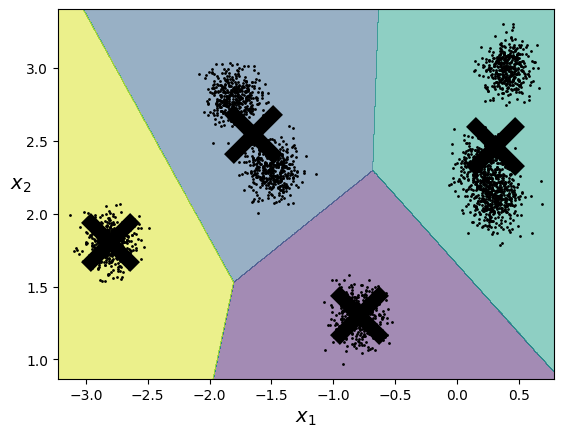

In [22]:
kmeans = KMeans(n_clusters=4, random_state=11238)
fit_results = kmeans.fit_predict(X_mat)
gfx.plot_decision_boundaries(kmeans, X_mat)

## Variabilidad del algoritmo de agrupación

En la variante más simple del algoritmo KMeans los centroides se inicializan de forma aleatoria, y éste busca mejorar de forma gradual la posición de los centroides.

Un problema substancial de ésto es que se pueden llegar a soluciones distintas dependiendo de la semilla pseudoaleatoria.

En el siguiente ejemplo graficamos dos soluciones para un modelo con 7 grupos, donde sólo varían `random_state`.

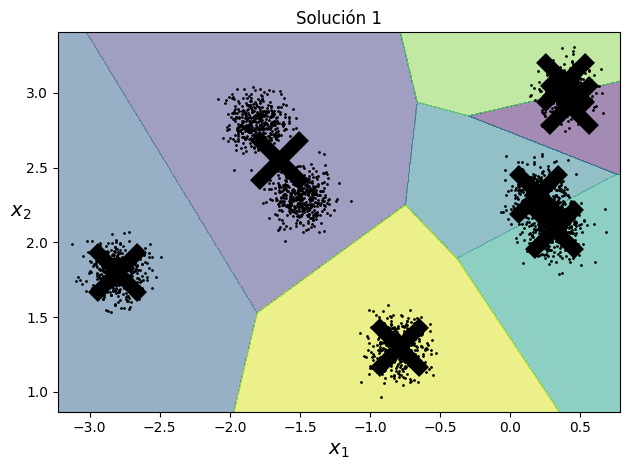

In [23]:
init_1 = KMeans(n_clusters=7, random_state=5342, init="random", n_init=1)
init_1.fit(X_mat)
gfx.plot_decision_boundaries(init_1, X_mat)
plt.title('Solución 1')
plt.tight_layout()

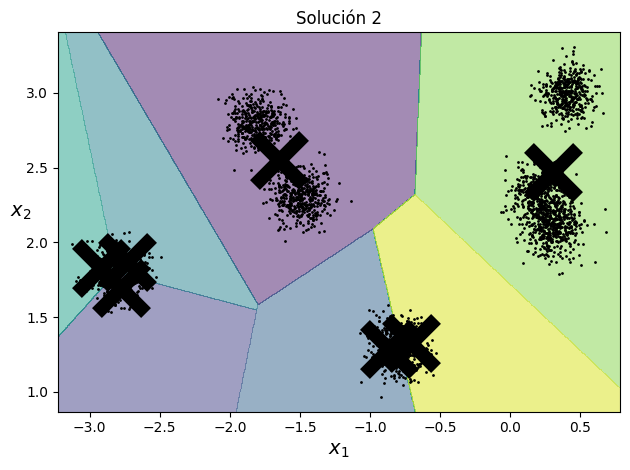

In [24]:
init_2 = KMeans(n_clusters=7, random_state=138, init="random", n_init=1)
init_2.fit(X_mat)
plt.title('Solución 2')
gfx.plot_decision_boundaries(init_2, X_mat)
plt.tight_layout()